In [21]:
# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("data/sales_data.csv")

print("Dataset Loaded Successfully!")

print("Shape:", df.shape)
display(df.head())

Dataset Loaded Successfully!
Shape: (100, 7)


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [22]:
# ==========================================
# DATA EXPLORATION
# ==========================================

print("Dataset Information")
df.info()

print("\nSummary Statistics")
display(df.describe())

print("\nColumns")
print(df.columns)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         100 non-null    str  
 1   Product      100 non-null    str  
 2   Quantity     100 non-null    int64
 3   Price        100 non-null    int64
 4   Customer_ID  100 non-null    str  
 5   Region       100 non-null    str  
 6   Total_Sales  100 non-null    int64
dtypes: int64(3), str(4)
memory usage: 5.6 KB

Summary Statistics


,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000



Columns
Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='str')

Missing Values
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Duplicate Records
0


In [23]:
# ==========================================
# DATA CLEANING
# ==========================================

df = df.drop_duplicates()

df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month

print("Dataset Cleaned Successfully!")

Dataset Cleaned Successfully!


In [24]:
# ==========================================
# SALES ANALYSIS
# ==========================================

total_revenue = df["Total_Sales"].sum()
average_sales = df["Total_Sales"].mean()
highest_sale = df["Total_Sales"].max()
lowest_sale = df["Total_Sales"].min()

best_product = df.groupby("Product")["Total_Sales"].sum().idxmax()

print("="*60)
print("INTERACTIVE SALES DASHBOARD REPORT")
print("="*60)

print(f"Total Revenue : ₹{total_revenue:,.0f}")
print(f"Average Sales : ₹{average_sales:,.2f}")
print(f"Highest Sale  : ₹{highest_sale:,.0f}")
print(f"Lowest Sale   : ₹{lowest_sale:,.0f}")
print(f"Best Product  : {best_product}")

INTERACTIVE SALES DASHBOARD REPORT
Total Revenue : ₹12,365,048
Average Sales : ₹123,650.48
Highest Sale  : ₹373,932
Lowest Sale   : ₹6,540
Best Product  : Laptop


In [25]:
# ==========================================
# GROUPBY
# ==========================================

sales_by_product = df.groupby("Product")["Total_Sales"].sum()

sales_by_region = df.groupby("Region")["Total_Sales"].sum()

monthly_sales = df.groupby("Month")["Total_Sales"].sum()

display(sales_by_product)

display(sales_by_region)

display(monthly_sales)

Product
Headphones    1384033
Laptop        3889210
Monitor       1348071
Phone         2859394
Tablet        2884340
Name: Total_Sales, dtype: int64

Region
East     2519639
North    3983635
South    3737852
West     2123922
Name: Total_Sales, dtype: int64

Month
1    4120524
2    2656050
3    4485006
4    1103468
Name: Total_Sales, dtype: int64

In [26]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


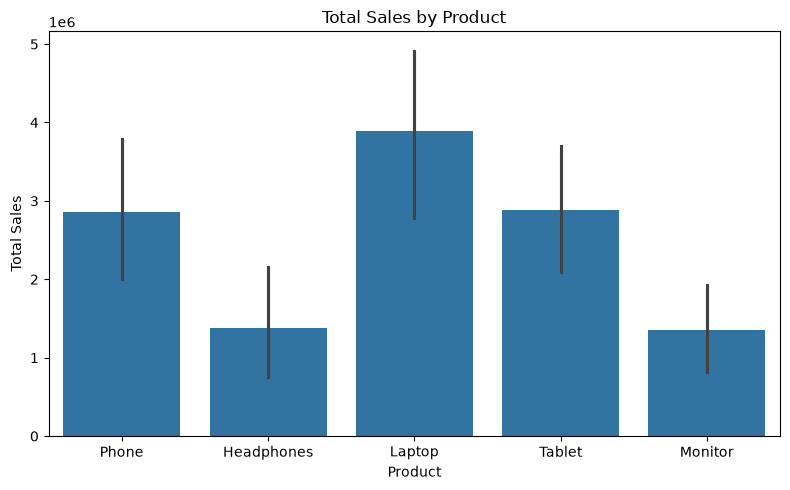

In [27]:
# ==========================================
# BAR CHART
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Product",
    y="Total_Sales",
    estimator=sum
)

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig("visualizations/bar_chart.png")

plt.show()

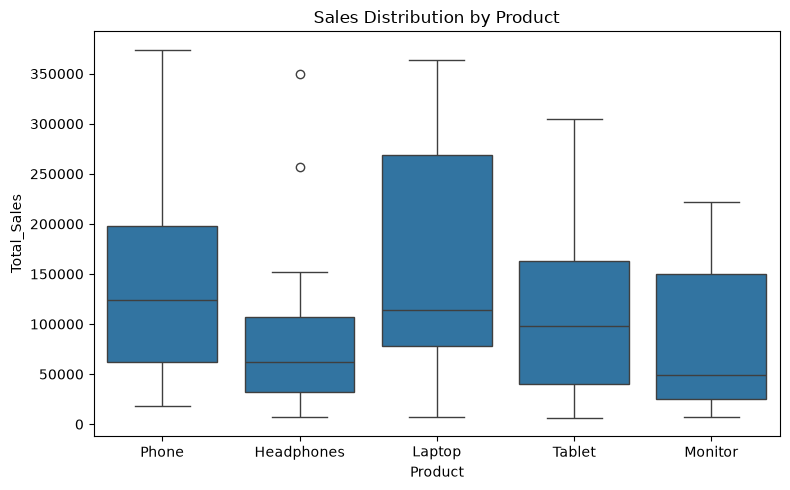

In [28]:
# ==========================================
# BOX PLOT
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Product",
    y="Total_Sales"
)

plt.title("Sales Distribution by Product")

plt.tight_layout()

plt.savefig("visualizations/box_plot.png")

plt.show()

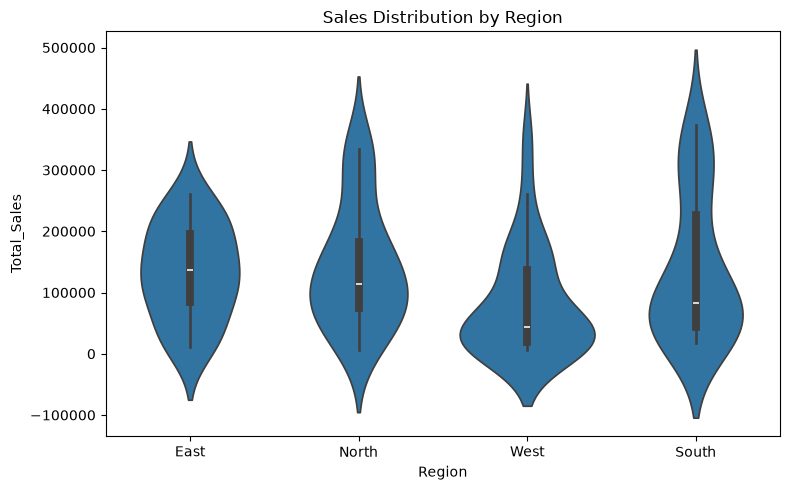

In [29]:
# ==========================================
# VIOLIN PLOT
# ==========================================

plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="Region",
    y="Total_Sales"
)

plt.title("Sales Distribution by Region")

plt.tight_layout()

plt.savefig("visualizations/violin_plot.png")

plt.show()

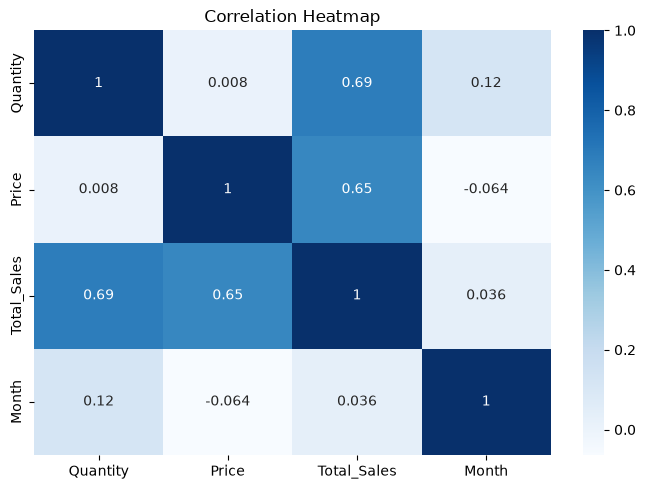

In [30]:
# ==========================================
# HEATMAP
# ==========================================

plt.figure(figsize=(7,5))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("visualizations/heatmap.png")

plt.show()

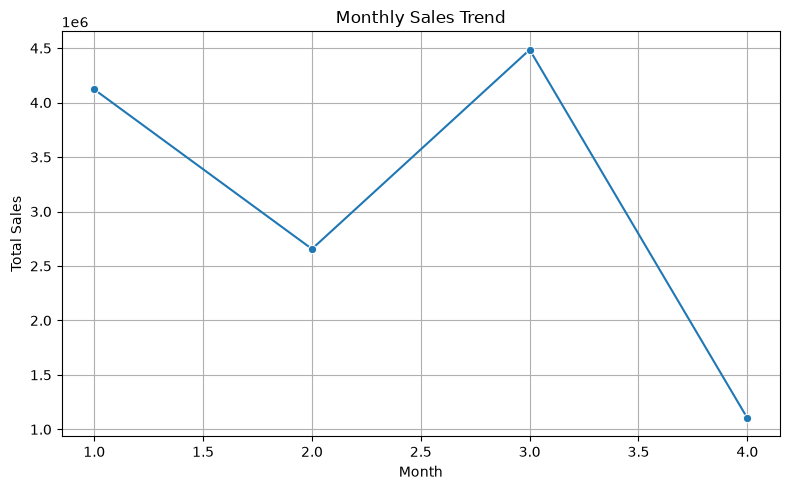

In [31]:
# ==========================================
# LINE CHART
# ==========================================

plt.figure(figsize=(8,5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("visualizations/line_chart.png")

plt.show()

In [32]:
# ==========================================
# INTERACTIVE DASHBOARD
# ==========================================

fig = px.bar(
    df,
    x="Product",
    y="Total_Sales",
    color="Region",
    title="Interactive Sales Dashboard",
    hover_data=["Quantity", "Price"]
)

fig.write_html("visualizations/interactive_dashboard.html")



In [33]:
# ==========================================
# DASHBOARD SUMMARY
# ==========================================

print("="*60)
print("INTERACTIVE SALES DASHBOARD")
print("="*60)

print(f"Total Revenue      : ₹{total_revenue:,.0f}")
print(f"Average Sales      : ₹{average_sales:,.2f}")
print(f"Highest Sale       : ₹{highest_sale:,.0f}")
print(f"Lowest Sale        : ₹{lowest_sale:,.0f}")
print(f"Best Product       : {best_product}")

highest_region = sales_by_region.idxmax()

print(f"Highest Region     : {highest_region}")

print("\nBUSINESS INSIGHTS")
print("- Laptop generated the highest revenue.")
print("- North region achieved the highest sales.")
print("- Heatmap shows relationships between numerical variables.")
print("- Box plot highlights sales distribution and outliers.")
print("- Violin plot visualizes regional sales density.")
print("- Interactive dashboard enables dynamic data exploration.")

print("="*60)

INTERACTIVE SALES DASHBOARD
Total Revenue      : ₹12,365,048
Average Sales      : ₹123,650.48
Highest Sale       : ₹373,932
Lowest Sale        : ₹6,540
Best Product       : Laptop
Highest Region     : North

BUSINESS INSIGHTS
- Laptop generated the highest revenue.
- North region achieved the highest sales.
- Heatmap shows relationships between numerical variables.
- Box plot highlights sales distribution and outliers.
- Violin plot visualizes regional sales density.
- Interactive dashboard enables dynamic data exploration.
